<a href="https://colab.research.google.com/github/Amirhosseinpoor/VQVAE_ROP/blob/main/VQVAE_ROP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lpips optuna
!pip install --upgrade pip
!pip install torch torchvision tqdm pyyaml pillow
!pip install -q "torchmetrics[image]" torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 985.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
# Cell 1: Install required packages (Colab) and import libraries
# Run this cell first. Installs will be skipped if packages are present.

import sys
import os

# Try imports and install missing packages
missing = []
try:
    import lpips
except Exception:
    missing.append("lpips")
try:
    import optuna
except Exception:
    missing.append("optuna")
try:
    import skimage
except Exception:
    missing.append("scikit-image")
if missing:
    print("Installing:", missing)
    os.system("pip install --quiet " + " ".join(missing))
!pip install torchmetrics
import torchmetrics

# Standard imports
import math
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
from glob import glob
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from torchvision.utils import make_grid

import lpips
import optuna
from skimage.metrics import structural_similarity as ssim_sk
from skimage.metrics import peak_signal_noise_ratio as psnr_sk
from skimage.filters import threshold_otsu

print("PyTorch version:", torch.__version__)
print("Device available:", "cuda" if torch.cuda.is_available() else "cpu")


PyTorch version: 2.10.0+cu128
Device available: cuda


In [ ]:
!gdown '1U13PNf1GqRjHo3Y-r3E905RjBXV9b8qd'

Downloading...
From (original): https://drive.google.com/uc?id=1U13PNf1GqRjHo3Y-r3E905RjBXV9b8qd
From (redirected): https://drive.google.com/uc?id=1U13PNf1GqRjHo3Y-r3E905RjBXV9b8qd&confirm=t&uuid=39292001-704d-474a-b003-46f6c67d2f6c
To: /content/Stage_dataset_2(1).zip
100% 202M/202M [00:01<00:00, 134MB/s]


In [ ]:
!gdown '19n6l2MUqDgM3tOIRRhQGDw-XqeUvpjsR'

Downloading...
From (original): https://drive.google.com/uc?id=19n6l2MUqDgM3tOIRRhQGDw-XqeUvpjsR
From (redirected): https://drive.google.com/uc?id=19n6l2MUqDgM3tOIRRhQGDw-XqeUvpjsR&confirm=t&uuid=899567df-b91b-435c-93b9-ab61ec987de8
To: /content/dataset_model.zip
100% 409M/409M [00:02<00:00, 154MB/s]


In [ ]:
!gdown '1JcAg9EXOKnzdJ23vYFbZMrCCgMX4m3K7'

Downloading...
From (original): https://drive.google.com/uc?id=1JcAg9EXOKnzdJ23vYFbZMrCCgMX4m3K7
From (redirected): https://drive.google.com/uc?id=1JcAg9EXOKnzdJ23vYFbZMrCCgMX4m3K7&confirm=t&uuid=19af2a26-4a41-4669-9b5a-522152d9d1e6
To: /content/Farabi_Dataset2_Zip(1).zip
100% 554M/554M [00:06<00:00, 79.3MB/s]


In [ ]:
!unzip '/content/dataset_model.zip' -d '/content/data/'

Archive:  /content/dataset_model.zip
   creating: /content/data/dataset_model/
   creating: /content/data/dataset_model/stage0/
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_1.jpg  
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_2.jpg  
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_3.jpg  
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_4.jpg  
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_5.jpg  
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_6.jpg  
  inflating: /content/data/dataset_model/stage0/052_M_GA26_BW820_PA31_DG1_PF0_D1_S01_7.jpg  
  inflating: /content/data/dataset_model/stage0/066_F_GA26_BW810_PA31_DG1_PF0_D1_S01_1.jpg  
  inflating: /content/data/dataset_model/stage0/066_F_GA26_BW810_PA31_DG1_PF0_D1_S01_10.jpg  
  inflating: /content/data/dataset

In [ ]:
!unzip '/content/Farabi_Dataset2_Zip(1).zip' -d '/content/data/'

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/Plus/No Plus/44d5365e-0418-4740-80f1-39d82d9ba836.12.jpg  
  inflating: /content/data/Plus/No Plus/44d5365e-0418-4740-80f1-39d82d9ba836.24.jpg  
  inflating: /content/data/Plus/No Plus/44d5365e-0418-4740-80f1-39d82d9ba836.1.jpg  
  inflating: /content/data/Plus/No Plus/44d5365e-0418-4740-80f1-39d82d9ba836.3.jpg  
  inflating: /content/data/Plus/No Plus/44d5365e-0418-4740-80f1-39d82d9ba836.10.jpg  
  inflating: /content/data/Plus/No Plus/4d3d48d0-91d6-4ee6-a1df-7b137ba50d0d.20.jpg  
  inflating: /content/data/Plus/No Plus/4d3d48d0-91d6-4ee6-a1df-7b137ba50d0d.23.jpg  
  inflating: /content/data/Plus/No Plus/4d3d48d0-91d6-4ee6-a1df-7b137ba50d0d.10.jpg  
  inflating: /content/data/Plus/No Plus/4d3d48d0-91d6-4ee6-a1df-7b137ba50d0d.11.jpg  
  inflating: /content/data/Plus/No Plus/4d3d48d0-91d6-4ee6-a1df-7b137ba50d0d.16.jpg  
  inflating: /content/data/Plus/No Plus/4d3d48d0-91d6-4ee6-a1df-7b137ba50d0d.12.jpg  
  inf

In [ ]:
!unzip '/content/Stage_dataset_2(1).zip' -d '/content/data/'

Archive:  /content/Stage_dataset_2(1).zip
   creating: /content/data/Stage_dataset_2/
   creating: /content/data/Stage_dataset_2/laser scars/
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_1.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_10.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_100.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_101.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_102.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_103.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_104.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_105.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_106.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_107.jpg  
  inflating: /content/data/Stage_dataset_2/laser scars/laser_scars_108.jpg  
  inflating: /

In [ ]:
!pip install --upgrade pip
!pip install torch torchvision tqdm pyyaml pillow

In [ ]:
import torch
import torch.nn as nn


def get_time_embedding(time_steps, temb_dim):
    r"""
    Convert time steps tensor into an embedding using the
    sinusoidal time embedding formula
    :param time_steps: 1D tensor of length batch size
    :param temb_dim: Dimension of the embedding
    :return: BxD embedding representation of B time steps
    """
    assert temb_dim % 2 == 0, "time embedding dimension must be divisible by 2"

    # factor = 10000^(2i/d_model)
    factor = 10000 ** ((torch.arange(
        start=0, end=temb_dim // 2, dtype=torch.float32, device=time_steps.device) / (temb_dim // 2))
    )

    # pos / factor
    # timesteps B -> B, 1 -> B, temb_dim
    t_emb = time_steps[:, None].repeat(1, temb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb


class DownBlock(nn.Module):
    r"""
    Down conv block with attention.
    Sequence of following block
    1. Resnet block with time embedding
    2. Attention block
    3. Downsample
    """

    def __init__(self, in_channels, out_channels, t_emb_dim,
                 down_sample, num_heads, num_layers, attn, norm_channels, cross_attn=False, context_dim=None):
        super().__init__()
        self.num_layers = num_layers
        self.down_sample = down_sample
        self.attn = attn
        self.context_dim = context_dim
        self.cross_attn = cross_attn
        self.t_emb_dim = t_emb_dim
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for i in range(num_layers)
            ]
        )
        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList([
                nn.Sequential(
                    nn.SiLU(),
                    nn.Linear(self.t_emb_dim, out_channels)
                )
                for _ in range(num_layers)
            ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels,
                              kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )

        if self.attn:
            self.attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels)
                 for _ in range(num_layers)]
            )

            self.attentions = nn.ModuleList(
                [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                 for _ in range(num_layers)]
            )

        if self.cross_attn:
            assert context_dim is not None, "Context Dimension must be passed for cross attention"
            self.cross_attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels)
                 for _ in range(num_layers)]
            )
            self.cross_attentions = nn.ModuleList(
                [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                 for _ in range(num_layers)]
            )
            self.context_proj = nn.ModuleList(
                [nn.Linear(context_dim, out_channels)
                 for _ in range(num_layers)]
            )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.down_sample_conv = nn.Conv2d(out_channels, out_channels,
                                          4, 2, 1) if self.down_sample else nn.Identity()

    def forward(self, x, t_emb=None, context=None):
        out = x
        for i in range(self.num_layers):
            # Resnet block of Unet
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            if self.t_emb_dim is not None:
                out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            if self.attn:
                # Attention block of Unet
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn

            if self.cross_attn:
                assert context is not None, "context cannot be None if cross attention layers are used"
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.cross_attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                assert context.shape[0] == x.shape[0] and context.shape[-1] == self.context_dim
                context_proj = self.context_proj[i](context)
                out_attn, _ = self.cross_attentions[i](in_attn, context_proj, context_proj)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn

        # Downsample
        out = self.down_sample_conv(out)
        return out


class MidBlock(nn.Module):
    r"""
    Mid conv block with attention.
    Sequence of following blocks
    1. Resnet block with time embedding
    2. Attention block
    3. Resnet block with time embedding
    """

    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads, num_layers, norm_channels, cross_attn=None, context_dim=None):
        super().__init__()
        self.num_layers = num_layers
        self.t_emb_dim = t_emb_dim
        self.context_dim = context_dim
        self.cross_attn = cross_attn
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers + 1)
            ]
        )

        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList([
                nn.Sequential(
                    nn.SiLU(),
                    nn.Linear(t_emb_dim, out_channels)
                )
                for _ in range(num_layers + 1)
            ])
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers + 1)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [nn.GroupNorm(norm_channels, out_channels)
             for _ in range(num_layers)]
        )

        self.attentions = nn.ModuleList(
            [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
             for _ in range(num_layers)]
        )
        if self.cross_attn:
            assert context_dim is not None, "Context Dimension must be passed for cross attention"
            self.cross_attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels)
                 for _ in range(num_layers)]
            )
            self.cross_attentions = nn.ModuleList(
                [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                 for _ in range(num_layers)]
            )
            self.context_proj = nn.ModuleList(
                [nn.Linear(context_dim, out_channels)
                 for _ in range(num_layers)]
            )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers + 1)
            ]
        )

    def forward(self, x, t_emb=None, context=None):
        out = x

        # First resnet block
        resnet_input = out
        out = self.resnet_conv_first[0](out)
        if self.t_emb_dim is not None:
            out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)

        for i in range(self.num_layers):
            # Attention Block
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

            if self.cross_attn:
                assert context is not None, "context cannot be None if cross attention layers are used"
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.cross_attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                assert context.shape[0] == x.shape[0] and context.shape[-1] == self.context_dim
                context_proj = self.context_proj[i](context)
                out_attn, _ = self.cross_attentions[i](in_attn, context_proj, context_proj)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn


            # Resnet Block
            resnet_input = out
            out = self.resnet_conv_first[i + 1](out)
            if self.t_emb_dim is not None:
                out = out + self.t_emb_layers[i + 1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i + 1](out)
            out = out + self.residual_input_conv[i + 1](resnet_input)

        return out


class UpBlock(nn.Module):
    r"""
    Up conv block with attention.
    Sequence of following blocks
    1. Upsample
    1. Concatenate Down block output
    2. Resnet block with time embedding
    3. Attention Block
    """

    def __init__(self, in_channels, out_channels, t_emb_dim,
                 up_sample, num_heads, num_layers, attn, norm_channels):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample
        self.t_emb_dim = t_emb_dim
        self.attn = attn
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers)
            ]
        )

        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList([
                nn.Sequential(
                    nn.SiLU(),
                    nn.Linear(t_emb_dim, out_channels)
                )
                for _ in range(num_layers)
            ])

        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )
        if self.attn:
            self.attention_norms = nn.ModuleList(
                [
                    nn.GroupNorm(norm_channels, out_channels)
                    for _ in range(num_layers)
                ]
            )

            self.attentions = nn.ModuleList(
                [
                    nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                    for _ in range(num_layers)
                ]
            )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.up_sample_conv = nn.ConvTranspose2d(in_channels, in_channels,
                                                 4, 2, 1) \
            if self.up_sample else nn.Identity()

    def forward(self, x, out_down=None, t_emb=None):
        # Upsample
        x = self.up_sample_conv(x)

        # Concat with Downblock output
        if out_down is not None:
            x = torch.cat([x, out_down], dim=1)

        out = x
        for i in range(self.num_layers):
            # Resnet Block
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            if self.t_emb_dim is not None:
                out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            # Self Attention
            if self.attn:
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn
        return out


class UpBlockUnet(nn.Module):
    r"""
    Up conv block with attention.
    Sequence of following blocks
    1. Upsample
    1. Concatenate Down block output
    2. Resnet block with time embedding
    3. Attention Block
    """

    def __init__(self, in_channels, out_channels, t_emb_dim, up_sample,
                 num_heads, num_layers, norm_channels, cross_attn=False, context_dim=None):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample
        self.t_emb_dim = t_emb_dim
        self.cross_attn = cross_attn
        self.context_dim = context_dim
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers)
            ]
        )

        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList([
                nn.Sequential(
                    nn.SiLU(),
                    nn.Linear(t_emb_dim, out_channels)
                )
                for _ in range(num_layers)
            ])

        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )

        self.attention_norms = nn.ModuleList(
            [
                nn.GroupNorm(norm_channels, out_channels)
                for _ in range(num_layers)
            ]
        )

        self.attentions = nn.ModuleList(
            [
                nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                for _ in range(num_layers)
            ]
        )

        if self.cross_attn:
            assert context_dim is not None, "Context Dimension must be passed for cross attention"
            self.cross_attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels)
                 for _ in range(num_layers)]
            )
            self.cross_attentions = nn.ModuleList(
                [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                 for _ in range(num_layers)]
            )
            self.context_proj = nn.ModuleList(
                [nn.Linear(context_dim, out_channels)
                 for _ in range(num_layers)]
            )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.up_sample_conv = nn.ConvTranspose2d(in_channels // 2, in_channels // 2,
                                                 4, 2, 1) \
            if self.up_sample else nn.Identity()

    def forward(self, x, out_down=None, t_emb=None, context=None):
        x = self.up_sample_conv(x)
        if out_down is not None:
            x = torch.cat([x, out_down], dim=1)

        out = x
        for i in range(self.num_layers):
            # Resnet
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            if self.t_emb_dim is not None:
                out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)
            # Self Attention
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            # Cross Attention
            if self.cross_attn:
                assert context is not None, "context cannot be None if cross attention layers are used"
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.cross_attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                assert len(context.shape) == 3, \
                    "Context shape does not match B,_,CONTEXT_DIM"
                assert context.shape[0] == x.shape[0] and context.shape[-1] == self.context_dim,\
                    "Context shape does not match B,_,CONTEXT_DIM"
                context_proj = self.context_proj[i](context)
                out_attn, _ = self.cross_attentions[i](in_attn, context_proj, context_proj)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn

        return out



In [ ]:
# Cell 2 — VQVAE (exact as provided)
import torch
import torch.nn as nn
from types import SimpleNamespace  # used only if your DownBlock imports rely on other things

# WARNING: This cell expects that DownBlock, MidBlock, UpBlock exist.
# If you have those block classes defined elsewhere, define them in another cell first.
# Below is exactly the VQVAE class content you gave me:
# if you don't have models/blocks defined as files, define classes inline in another cell

class VQVAE(nn.Module):
    def __init__(self, im_channels, model_config):
        super().__init__()
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        # To disable attention in Downblock of Encoder and Upblock of Decoder
        self.attns = model_config['attn_down']

        # Latent Dimension
        self.z_channels = model_config['z_channels']
        self.codebook_size = model_config['codebook_size']
        self.norm_channels = model_config['norm_channels']
        self.num_heads = model_config['num_heads']

        # Assertion to validate the channel information
        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-1]
        assert len(self.down_sample) == len(self.down_channels) - 1
        assert len(self.attns) == len(self.down_channels) - 1

        # Wherever we use downsampling in encoder correspondingly use
        # upsampling in decoder
        self.up_sample = list(reversed(self.down_sample))

        ##################### Encoder ######################
        self.encoder_conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1))

        # Downblock + Midblock
        self.encoder_layers = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.encoder_layers.append(DownBlock(self.down_channels[i], self.down_channels[i + 1],
                                                 t_emb_dim=None, down_sample=self.down_sample[i],
                                                 num_heads=self.num_heads,
                                                 num_layers=self.num_down_layers,
                                                 attn=self.attns[i],
                                                 norm_channels=self.norm_channels))

        self.encoder_mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.encoder_mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i + 1],
                                              t_emb_dim=None,
                                              num_heads=self.num_heads,
                                              num_layers=self.num_mid_layers,
                                              norm_channels=self.norm_channels))

        self.encoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[-1])
        self.encoder_conv_out = nn.Conv2d(self.down_channels[-1], self.z_channels, kernel_size=3, padding=1)

        # Pre Quantization Convolution
        self.pre_quant_conv = nn.Conv2d(self.z_channels, self.z_channels, kernel_size=1)

        # Codebook
        self.embedding = nn.Embedding(self.codebook_size, self.z_channels)
        ####################################################

        ##################### Decoder ######################

        # Post Quantization Convolution
        self.post_quant_conv = nn.Conv2d(self.z_channels, self.z_channels, kernel_size=1)
        self.decoder_conv_in = nn.Conv2d(self.z_channels, self.mid_channels[-1], kernel_size=3, padding=(1, 1))

        # Midblock + Upblock
        self.decoder_mids = nn.ModuleList([])
        for i in reversed(range(1, len(self.mid_channels))):
            self.decoder_mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i - 1],
                                              t_emb_dim=None,
                                              num_heads=self.num_heads,
                                              num_layers=self.num_mid_layers,
                                              norm_channels=self.norm_channels))

        self.decoder_layers = nn.ModuleList([])
        for i in reversed(range(1, len(self.down_channels))):
            self.decoder_layers.append(UpBlock(self.down_channels[i], self.down_channels[i - 1],
                                               t_emb_dim=None, up_sample=self.down_sample[i - 1],
                                               num_heads=self.num_heads,
                                               num_layers=self.num_up_layers,
                                               attn=self.attns[i-1],
                                               norm_channels=self.norm_channels))

        self.decoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[0])
        self.decoder_conv_out = nn.Conv2d(self.down_channels[0], im_channels, kernel_size=3, padding=1)

    def quantize(self, x):
        B, C, H, W = x.shape

        # B, C, H, W -> B, H, W, C
        x = x.permute(0, 2, 3, 1)

        # B, H, W, C -> B, H*W, C
        x = x.reshape(x.size(0), -1, x.size(-1))

        # Find nearest embedding/codebook vector
        # dist between (B, H*W, C) and (B, K, C) -> (B, H*W, K)
        dist = torch.cdist(x, self.embedding.weight[None, :].repeat((x.size(0), 1, 1)))
        # (B, H*W)
        min_encoding_indices = torch.argmin(dist, dim=-1)

        # Replace encoder output with nearest codebook
        # quant_out -> B*H*W, C
        quant_out = torch.index_select(self.embedding.weight, 0, min_encoding_indices.view(-1))

        # x -> B*H*W, C
        x = x.reshape((-1, x.size(-1)))
        commmitment_loss = torch.mean((quant_out.detach() - x) ** 2)
        codebook_loss = torch.mean((quant_out - x.detach()) ** 2)
        quantize_losses = {
            'codebook_loss': codebook_loss,
            'commitment_loss': commmitment_loss
        }
        # Straight through estimation
        quant_out = x + (quant_out - x).detach()

        # quant_out -> B, C, H, W
        quant_out = quant_out.reshape((B, H, W, C)).permute(0, 3, 1, 2)
        min_encoding_indices = min_encoding_indices.reshape((-1, quant_out.size(-2), quant_out.size(-1)))
        return quant_out, quantize_losses, min_encoding_indices

    def encode(self, x):
        out = self.encoder_conv_in(x)
        for idx, down in enumerate(self.encoder_layers):
            out = down(out)
        for mid in self.encoder_mids:
            out = mid(out)
        out = self.encoder_norm_out(out)
        out = nn.SiLU()(out)
        out = self.encoder_conv_out(out)
        out = self.pre_quant_conv(out)
        out, quant_losses, _ = self.quantize(out)
        return out, quant_losses

    def decode(self, z):
        out = z
        out = self.post_quant_conv(out)
        out = self.decoder_conv_in(out)
        for mid in self.decoder_mids:
            out = mid(out)
        for idx, up in enumerate(self.decoder_layers):
            out = up(out)

        out = self.decoder_norm_out(out)
        out = nn.SiLU()(out)
        out = self.decoder_conv_out(out)
        return out

    def forward(self, x):
        z, quant_losses = self.encode(x)
        out = self.decode(z)
        return out, z, quant_losses


In [ ]:
# Cell — download LPIPS weights to /tmp (exact path expected by your code)

import os
import urllib.request

os.makedirs("/tmp/weights/v0.1", exist_ok=True)

url = "https://raw.githubusercontent.com/richzhang/PerceptualSimilarity/master/lpips/weights/v0.1/vgg.pth"
out_path = "/tmp/weights/v0.1/vgg.pth"

if not os.path.exists(out_path):
    print("Downloading LPIPS weights...")
    urllib.request.urlretrieve(url, out_path)
    print("Saved to:", out_path)
else:
    print("LPIPS weights already exist:", out_path)


Saved to: /tmp/weights/v0.1/vgg.pth


In [ ]:
# Cell 3 — LPIPS (exact as provided)
from __future__ import absolute_import
from collections import namedtuple
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.autograd import Variable
import numpy as np
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def spatial_average(in_tens, keepdim=True):
    return in_tens.mean([2, 3], keepdim=keepdim)

class vgg16(torch.nn.Module):
    def __init__(self, requires_grad=False, pretrained=True):
        super(vgg16, self).__init__()
        vgg_pretrained_features = torchvision.models.vgg16(pretrained=pretrained).features
        self.slice1 = torch.nn.Sequential()
        self.slice2 = torch.nn.Sequential()
        self.slice3 = torch.nn.Sequential()
        self.slice4 = torch.nn.Sequential()
        self.slice5 = torch.nn.Sequential()
        self.N_slices = 5
        for x in range(4):
            self.slice1.add_module(str(x), vgg_pretrained_features[x])
        for x in range(4, 9):
            self.slice2.add_module(str(x), vgg_pretrained_features[x])
        for x in range(9, 16):
            self.slice3.add_module(str(x), vgg_pretrained_features[x])
        for x in range(16, 23):
            self.slice4.add_module(str(x), vgg_pretrained_features[x])
        for x in range(23, 30):
            self.slice5.add_module(str(x), vgg_pretrained_features[x])

        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_2 = h
        h = self.slice2(h)
        h_relu2_2 = h
        h = self.slice3(h)
        h_relu3_3 = h
        h = self.slice4(h)
        h_relu4_3 = h
        h = self.slice5(h)
        h_relu5_3 = h
        vgg_outputs = namedtuple("VggOutputs", ['relu1_2', 'relu2_2', 'relu3_3', 'relu4_3', 'relu5_3'])
        out = vgg_outputs(h_relu1_2, h_relu2_2, h_relu3_3, h_relu4_3, h_relu5_3)
        return out

class LPIPS(nn.Module):
    def __init__(self, net='vgg', version='0.1', use_dropout=True):
        super(LPIPS, self).__init__()
        self.version = version
        self.scaling_layer = ScalingLayer()
        self.chns = [64, 128, 256, 512, 512]
        self.L = len(self.chns)
        self.net = vgg16(pretrained=True, requires_grad=False)
        self.lin0 = NetLinLayer(self.chns[0], use_dropout=use_dropout)
        self.lin1 = NetLinLayer(self.chns[1], use_dropout=use_dropout)
        self.lin2 = NetLinLayer(self.chns[2], use_dropout=use_dropout)
        self.lin3 = NetLinLayer(self.chns[3], use_dropout=use_dropout)
        self.lin4 = NetLinLayer(self.chns[4], use_dropout=use_dropout)
        self.lins = [self.lin0, self.lin1, self.lin2, self.lin3, self.lin4]
        self.lins = nn.ModuleList(self.lins)
        import inspect
        import os
        model_path = os.path.abspath(
            os.path.join(inspect.getfile(self.__init__), '..', 'weights/v%s/%s.pth' % (version, net)))
        print('Loading model from: %s' % model_path)
        self.load_state_dict(torch.load(model_path, map_location=device), strict=False)
        self.eval()
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, in0, in1, normalize=False):
        if normalize:
            in0 = 2 * in0 - 1
            in1 = 2 * in1 - 1
        in0_input, in1_input = self.scaling_layer(in0), self.scaling_layer(in1)
        outs0, outs1 = self.net.forward(in0_input), self.net.forward(in1_input)
        feats0, feats1, diffs = {}, {}, {}
        for kk in range(self.L):
            feats0[kk], feats1[kk] = torch.nn.functional.normalize(outs0[kk], dim=1), torch.nn.functional.normalize(
                outs1[kk])
            diffs[kk] = (feats0[kk] - feats1[kk]) ** 2
        res = [spatial_average(self.lins[kk](diffs[kk]), keepdim=True) for kk in range(self.L)]
        val = 0
        for l in range(self.L):
            val += res[l]
        return val

class ScalingLayer(nn.Module):
    def __init__(self):
        super(ScalingLayer, self).__init__()
        self.register_buffer('shift', torch.Tensor([-.030, -.088, -.188])[None, :, None, None])
        self.register_buffer('scale', torch.Tensor([.458, .448, .450])[None, :, None, None])

    def forward(self, inp):
        return (inp - self.shift) / self.scale

class NetLinLayer(nn.Module):
    def __init__(self, chn_in, chn_out=1, use_dropout=False):
        super(NetLinLayer, self).__init__()
        layers = [nn.Dropout(), ] if (use_dropout) else []
        layers += [nn.Conv2d(chn_in, chn_out, 1, stride=1, padding=0, bias=False), ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        out = self.model(x)
        return out


In [ ]:
# Cell 4 — Discriminator (exact as provided)
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    r"""
    PatchGAN Discriminator.
    """
    def __init__(self, im_channels=3,
                 conv_channels=[64, 128, 256],
                 kernels=[4,4,4,4],
                 strides=[2,2,2,1],
                 paddings=[1,1,1,1]):
        super().__init__()
        self.im_channels = im_channels
        activation = nn.LeakyReLU(0.2)
        layers_dim = [self.im_channels] + conv_channels + [1]
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(layers_dim[i], layers_dim[i + 1],
                          kernel_size=kernels[i],
                          stride=strides[i],
                          padding=paddings[i],
                          bias=False if i !=0 else True),
                nn.BatchNorm2d(layers_dim[i + 1]) if i != len(layers_dim) - 2 and i != 0 else nn.Identity(),
                activation if i != len(layers_dim) - 2 else nn.Identity()
            )
            for i in range(len(layers_dim) - 1)
        ])

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer(out)
        return out

# Example quick test (optional)
if __name__ == '__main__':
    x = torch.randn((2,3, 256, 256))
    prob = Discriminator(im_channels=3)(x)
    print(prob.shape)


torch.Size([2, 1, 31, 31])


In [ ]:
# Cell 5 — merge + preprocess (adjusted to your structure)
import os
from PIL import Image
from pathlib import Path
import hashlib

src_roots = [
    '/content/data/Stage',
    '/content/data/Stage_dataset_2',
    '/content/data/dataset_model',
]

combined_root = '/content/data/combined_dataset'
TARGET_SIZE = (128, 128)
TARGET_MODE = 'RGB'  # grayscale (im_channels=1)

# Make combined subfolders
for stage_name in ['stage0','stage1', 'stage2', 'stage3','stage4','stage5']:
    os.makedirs(os.path.join(combined_root, stage_name), exist_ok=True)

def unique_name(src_path, suffix='.png'):
    h = hashlib.sha1(str(src_path).encode()).hexdigest()[:10]
    base = Path(src_path).stem
    return f"{base}_{h}{suffix}"

total = 0
for root in src_roots:
    if not os.path.exists(root):
        print(f"Warning — source does not exist: {root} (skipping)")
        continue
    for stage in ['stage0','stage1', 'stage2', 'stage3','stage4','stage5']:
        src_stage_dir = os.path.join(root, stage)
        if not os.path.isdir(src_stage_dir):
            # missing stage in this source
            print(f"Missing folder: {src_stage_dir} (skipping)")
            continue
        dst_stage_dir = os.path.join(combined_root, stage)
        for fname in os.listdir(src_stage_dir):
            src_f = os.path.join(src_stage_dir, fname)
            if not os.path.isfile(src_f):
                continue
            try:
                img = Image.open(src_f).convert(TARGET_MODE)
                # Pillow newer versions: use Image.Resampling.LANCZOS
                img = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
                out_name = unique_name(src_f)
                out_path = os.path.join(dst_stage_dir, out_name)
                img.save(out_path, format='PNG')
                total += 1
            except Exception as e:
                print(f"Skipping {src_f}: {e}")

print(f"Done. Total images in combined dataset: {total}")
print("Final dataset path:", combined_root)


Missing folder: /content/data/Stage_dataset_2/stage0 (skipping)
Missing folder: /content/data/Stage_dataset_2/stage4 (skipping)
Missing folder: /content/data/Stage_dataset_2/stage5 (skipping)
Missing folder: /content/data/dataset_model/stage4 (skipping)
Missing folder: /content/data/dataset_model/stage5 (skipping)
Done. Total images in combined dataset: 2627
Final dataset path: /content/data/combined_dataset


In [ ]:
# Cell 6 — ROPDataset class (inline)
import os
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T

class ROPDataset(Dataset):
    """
    Expects combined_root to have subfolders stage1, stage2, stage3
    returns images normalized to [-1, 1]
    """
    def __init__(self, root, im_size=28, im_channels=1):
        self.root = root
        self.im_size = im_size
        self.im_channels = im_channels
        self.paths = []
        for d in sorted(os.listdir(root)):
            dpath = os.path.join(root, d)
            if os.path.isdir(dpath):
                for fname in sorted(os.listdir(dpath)):
                    fpath = os.path.join(dpath, fname)
                    if os.path.isfile(fpath):
                        self.paths.append(fpath)
        self.transform = T.Compose([
            T.Resize((self.im_size, self.im_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.5]*self.im_channels, std=[0.5]*self.im_channels)
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p)
        if self.im_channels == 1:
            img = img.convert('L')
        else:
            img = img.convert('RGB')
        return self.transform(img)


In [ ]:
# Cell 7 — config (as dict)
config = {
    "dataset_params": {
        "im_path": "/content/data/combined_dataset",
        "im_channels": 3,
        "im_size": 128,
        "name": "rop"
    },
    "diffusion_params": {
        "num_timesteps": 1000,
        "beta_start": 0.0015,
        "beta_end": 0.0195
    },
    "ldm_params": {
        "down_channels": [128, 256, 256, 256],
        "mid_channels": [256, 256],
        "down_sample": [False, False, False],
        "attn_down": [True, True, True],
        "time_emb_dim": 256,
        "norm_channels": 32,
        "num_heads": 16,
        "conv_out_channels": 128,
        "num_down_layers": 2,
        "num_mid_layers": 2,
        "num_up_layers": 2
    },
    "autoencoder_params": {
        "z_channels": 3,
        "codebook_size": 20,
        "down_channels": [32, 64, 128],
        "mid_channels": [128, 128],
        "down_sample": [True, True],
        "attn_down": [False, False],
        "norm_channels": 32,
        "num_heads": 16,
        "num_down_layers": 1,
        "num_mid_layers": 1,
        "num_up_layers": 1
    },
    "train_params": {
        "seed": 1111,
        "task_name": "rop",
        "ldm_batch_size": 64,
        "autoencoder_batch_size": 16,
        "disc_start": 1000,
        "disc_weight": 0.5,
        "codebook_weight": 1,
        "commitment_beta": 0.2,
        "perceptual_weight": 1,
        "kl_weight": 0.000005,
        "ldm_epochs": 100,
        "autoencoder_epochs": 200,
        "num_samples": 25,
        "num_grid_rows": 5,
        "ldm_lr": 0.00001,
        "autoencoder_lr": 0.0001,
        "autoencoder_acc_steps": 1,
        "autoencoder_img_save_steps": 8,
        "save_latents": False,
        "vae_latent_dir_name": "vae_latents",
        "vqvae_latent_dir_name": "vqvae_latents",
        "ldm_ckpt_name": "ddpm_ckpt.pth",
        "vqvae_autoencoder_ckpt_name": "vqvae_autoencoder_ckpt.pth",
        "vae_autoencoder_ckpt_name": "vae_autoencoder_ckpt.pth",
        "vqvae_discriminator_ckpt_name": "vqvae_discriminator_ckpt.pth",
        "vae_discriminator_ckpt_name": "vae_discriminator_ckpt.pth"
    }
}


In [ ]:
!pip install --quiet torch-fidelity
!pip install -q "torchmetrics[image]" torch-fidelity

In [ ]:
# Cell 8 — training (inline, uses classes defined above)
import torch
import random
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchvision.utils import make_grid
import torchvision
import os
from torchmetrics.image.fid import FrechetInceptionDistance

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset_config = config['dataset_params']
autoencoder_config = config['autoencoder_params']
train_config = config['train_params']

# seeds
seed = train_config['seed']
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

# instantiate model exactly as given
model = VQVAE(im_channels=dataset_config['im_channels'],
              model_config=autoencoder_config).to(device)

# dataset + loader with Train/Val Split
im_dataset = ROPDataset(root=dataset_config['im_path'],
                        im_size=dataset_config['im_size'],
                        im_channels=dataset_config['im_channels'])

train_size = int(0.85 * len(im_dataset))
val_size = len(im_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(im_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=train_config['autoencoder_batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=train_config['autoencoder_batch_size'], shuffle=False)

# discriminator
discriminator = Discriminator(im_channels=dataset_config['im_channels']).to(device)

optimizer_d = Adam(discriminator.parameters(), lr=train_config['autoencoder_lr'], betas=(0.5, 0.999))
optimizer_g = Adam(model.parameters(), lr=train_config['autoencoder_lr'], betas=(0.5, 0.999))

recon_criterion = torch.nn.MSELoss()
disc_criterion = torch.nn.MSELoss()

# LPIPS instantiation — may fail if weight file not present.
try:
    lpips_model = LPIPS().eval().to(device)
except Exception as e:
    print("Warning: LPIPS instantiation failed (weights likely missing). Using zero-perceptual fallback. Error:", e)
    import torch.nn as nn
    class DummyLPIPS(nn.Module):
        def __init__(self):
            super().__init__()
        def forward(self, in0, in1, normalize=False):
            # return zeros shaped like a spatial map so torch.mean(...) works
            batch = in0.shape[0]
            return torch.zeros((batch,1,1,1), device=in0.device)
    lpips_model = DummyLPIPS().eval().to(device)

# output dirs
os.makedirs(train_config['task_name'], exist_ok=True)
os.makedirs(os.path.join(train_config['task_name'], 'vqvae_autoencoder_samples'), exist_ok=True)

disc_step_start = train_config['disc_start']
step_count = 0
acc_steps = train_config['autoencoder_acc_steps']
image_save_steps = train_config['autoencoder_img_save_steps']
img_save_count = 0
num_epochs = train_config['autoencoder_epochs']
fid_metric = FrechetInceptionDistance(feature=64).to(device) # feature=64 for faster compute, or 2048 for standard

# Early stopping and history variables
best_val_loss = float('inf')
patience = 8
patience_counter = 0

history = {
    'train_recon': [], 'val_recon': [],
    'train_perceptual': [], 'val_perceptual': [],
    'train_codebook': [], 'val_codebook': [],
    'train_g_loss': [], 'val_g_loss': [],
    'fid': []
}

for epoch_idx in range(num_epochs):
    recon_losses = []
    codebook_losses = []
    perceptual_losses = []
    disc_losses = []
    gen_losses = []
    losses = []

    optimizer_g.zero_grad()
    optimizer_d.zero_grad()

    for im in tqdm(train_loader):
        step_count += 1
        im = im.float().to(device)

        # forward
        output, z, quantize_losses = model(im)

        # Image Saving
        if step_count % image_save_steps == 0 or step_count == 1:
            sample_size = min(8, im.shape[0])
            save_output = torch.clamp(output[:sample_size], -1., 1.).detach().cpu()
            save_output = ((save_output + 1) / 2)
            save_input = ((im[:sample_size] + 1) / 2).detach().cpu()

            grid = make_grid(torch.cat([save_input, save_output], dim=0), nrow=sample_size)
            img = torchvision.transforms.ToPILImage()(grid)
            img.save(os.path.join(train_config['task_name'], 'vqvae_autoencoder_samples',
                                  'current_autoencoder_sample_{}.png'.format(img_save_count)))
            img_save_count += 1
            img.close()

        ######### Optimize Generator ##########
        recon_loss = recon_criterion(output, im)
        recon_losses.append(recon_loss.item())
        recon_loss_div = recon_loss / acc_steps

        g_loss = (recon_loss_div +
                  (train_config['codebook_weight'] * quantize_losses['codebook_loss'] / acc_steps) +
                  (train_config['commitment_beta'] * quantize_losses['commitment_loss'] / acc_steps))
        codebook_losses.append(train_config['codebook_weight'] * quantize_losses['codebook_loss'].item())

        if step_count > disc_step_start:
            disc_fake_pred = discriminator(output)
            disc_fake_loss = disc_criterion(disc_fake_pred,
                                            torch.ones_like(disc_fake_pred, device=disc_fake_pred.device))
            gen_losses.append(train_config['disc_weight'] * disc_fake_loss.item())
            g_loss = g_loss + train_config['disc_weight'] * disc_fake_loss / acc_steps

        lpips_loss = torch.mean(lpips_model(output, im))
        perceptual_losses.append(train_config['perceptual_weight'] * lpips_loss.item() if isinstance(lpips_loss, torch.Tensor) else 0.0)
        g_loss = g_loss + train_config['perceptual_weight'] * lpips_loss / acc_steps

        losses.append(g_loss.item() if isinstance(g_loss, torch.Tensor) else float(g_loss))
        g_loss.backward()
        #####################################

        ######### Optimize Discriminator #######
        if step_count > disc_step_start:
            fake = output
            disc_fake_pred = discriminator(fake.detach())
            disc_real_pred = discriminator(im)
            disc_fake_loss = disc_criterion(disc_fake_pred,
                                            torch.zeros_like(disc_fake_pred, device=disc_fake_pred.device))
            disc_real_loss = disc_criterion(disc_real_pred,
                                            torch.ones_like(disc_real_pred, device=disc_real_pred.device))
            disc_loss = train_config['disc_weight'] * (disc_fake_loss + disc_real_loss) / 2
            disc_losses.append(disc_loss.item())
            disc_loss = disc_loss / acc_steps
            disc_loss.backward()
            if step_count % acc_steps == 0:
                optimizer_d.step()
                optimizer_d.zero_grad()
        #####################################

        if step_count % acc_steps == 0:
            optimizer_g.step()
            optimizer_g.zero_grad()

    # epoch-end optimizer steps (as in original script)
    optimizer_d.step()
    optimizer_d.zero_grad()
    optimizer_g.step()
    optimizer_g.zero_grad()

    if len(disc_losses) > 0:
        print(
            'Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | '
            'Codebook : {:.4f} | G Loss : {:.4f} | D Loss {:.4f}'.
            format(epoch_idx + 1,
                   np.mean(recon_losses),
                   np.mean(perceptual_losses) if len(perceptual_losses)>0 else 0.0,
                   np.mean(codebook_losses),
                   np.mean(gen_losses) if len(gen_losses)>0 else 0.0,
                   np.mean(disc_losses)))
    else:
        print('Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | Codebook : {:.4f}'.
              format(epoch_idx + 1,
                     np.mean(recon_losses),
                     np.mean(perceptual_losses) if len(perceptual_losses)>0 else 0.0,
                     np.mean(codebook_losses) if len(codebook_losses)>0 else 0.0))

    torch.save(model.state_dict(), os.path.join(train_config['task_name'],
                                                train_config['vqvae_autoencoder_ckpt_name']))
    torch.save(discriminator.state_dict(), os.path.join(train_config['task_name'],
                                                        train_config['vqvae_discriminator_ckpt_name']))

    # ------------------ NEW: Validation Loop & Metrics ------------------
    model.eval()
    val_recon_losses = []
    val_perceptual_losses = []
    val_codebook_losses = []
    val_g_losses = []

    with torch.no_grad():
        for val_im in val_loader:
            val_im = val_im.float().to(device)
            val_out, _, val_quantize_losses = model(val_im)

            # Calculate Val Losses
            v_recon = recon_criterion(val_out, val_im)
            val_recon_losses.append(v_recon.item())

            v_lpips = torch.mean(lpips_model(val_out, val_im))
            val_perceptual_losses.append(train_config['perceptual_weight'] * v_lpips.item())

            v_codebook = train_config['codebook_weight'] * val_quantize_losses['codebook_loss'].item()
            val_codebook_losses.append(v_codebook)

            v_g_loss = v_recon + v_codebook + (train_config['commitment_beta'] * val_quantize_losses['commitment_loss']) + (train_config['perceptual_weight'] * v_lpips)
            val_g_losses.append(v_g_loss.item())

            # Update FID (requires uint8 images [0, 255])
            val_im_uint8 = ((val_im + 1) / 2 * 255).to(torch.uint8)
            val_out_uint8 = ((torch.clamp(val_out, -1., 1.) + 1) / 2 * 255).to(torch.uint8)

            # FID requires 3 channels. Repeat if grayscale.
            if val_im_uint8.shape[1] == 1:
                val_im_uint8 = val_im_uint8.repeat(1, 3, 1, 1)
                val_out_uint8 = val_out_uint8.repeat(1, 3, 1, 1)

            fid_metric.update(val_im_uint8, real=True)
            fid_metric.update(val_out_uint8, real=False)

    model.train() # Switch back to train mode for next epoch

    # Save to history
    current_val_recon = np.mean(val_recon_losses)
    current_fid = fid_metric.compute().item()
    fid_metric.reset()

    history['train_recon'].append(np.mean(recon_losses))
    history['val_recon'].append(current_val_recon)
    history['train_perceptual'].append(np.mean(perceptual_losses) if len(perceptual_losses)>0 else 0)
    history['val_perceptual'].append(np.mean(val_perceptual_losses))
    history['train_codebook'].append(np.mean(codebook_losses))
    history['val_codebook'].append(np.mean(val_codebook_losses))
    history['train_g_loss'].append(np.mean(losses))
    history['val_g_loss'].append(np.mean(val_g_losses))
    history['fid'].append(current_fid)

    print(f'Validation -> Recon: {current_val_recon:.4f} | FID Score: {current_fid:.4f}')

    # Early Stopping Logic (based on validation reconstruction loss)
    if current_val_recon < best_val_loss:
        best_val_loss = current_val_recon
        patience_counter = 0
        # Save the "best" model checkpoint
        torch.save(model.state_dict(), os.path.join(train_config['task_name'], 'best_' + train_config['vqvae_autoencoder_ckpt_name']))
    else:
        patience_counter += 1
        print(f'Early stopping patience: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print("Early stopping triggered. Training stopped.")
            break
    # --------------------------------------------------------------------

print('Done Training...')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 67.0MB/s]


Loading model from: /tmp/weights/v0.1/vgg.pth


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 184MB/s]
100%|██████████| 140/140 [01:05<00:00,  2.12it/s]


...

Finished epoch: 44 | Recon Loss : 0.0072 | Perceptual Loss : 0.0926 | Codebook : 0.0902 | G Loss : 0.0441 | D Loss 0.1373
Validation -> Recon: 0.0216 | FID Score: 0.4524
Early stopping patience: 6/8


100%|██████████| 140/140 [01:13<00:00,  1.91it/s]


Finished epoch: 45 | Recon Loss : 0.0072 | Perceptual Loss : 0.0905 | Codebook : 0.0899 | G Loss : 0.0442 | D Loss 0.1392
Validation -> Recon: 0.0062 | FID Score: 0.2200
Early stopping patience: 7/8


100%|██████████| 140/140 [01:13<00:00,  1.90it/s]


Finished epoch: 46 | Recon Loss : 0.0071 | Perceptual Loss : 0.0900 | Codebook : 0.0904 | G Loss : 0.0441 | D Loss 0.1366
Validation -> Recon: 0.0121 | FID Score: 0.2819
Early stopping patience: 8/8
Early stopping triggered. Training stopped.
Done Training...


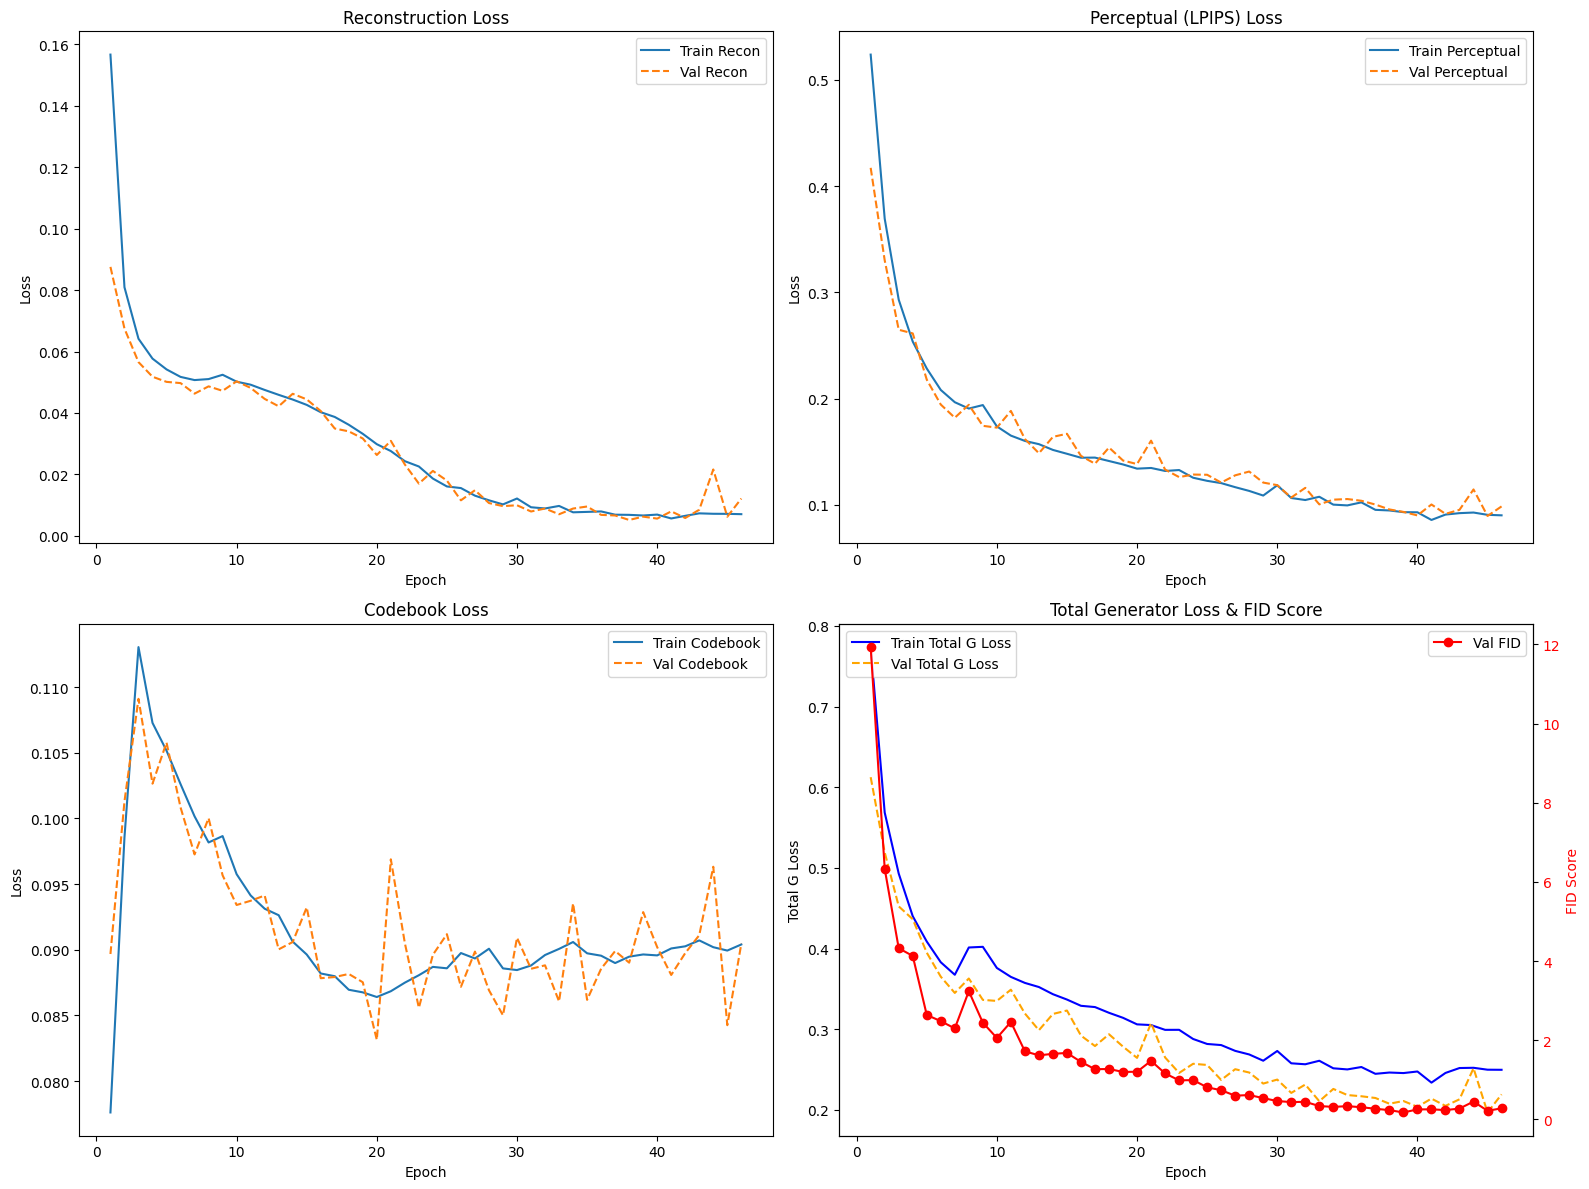

In [ ]:
# --- Plotting the 4 Loss Figures & Metrics ---
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_recon']) + 1)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Reconstruction Loss
axs[0, 0].plot(epochs_range, history['train_recon'], label='Train Recon')
axs[0, 0].plot(epochs_range, history['val_recon'], label='Val Recon', linestyle='--')
axs[0, 0].set_title('Reconstruction Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()

# 2. Perceptual Loss
axs[0, 1].plot(epochs_range, history['train_perceptual'], label='Train Perceptual')
axs[0, 1].plot(epochs_range, history['val_perceptual'], label='Val Perceptual', linestyle='--')
axs[0, 1].set_title('Perceptual (LPIPS) Loss')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()

# 3. Codebook Loss
axs[1, 0].plot(epochs_range, history['train_codebook'], label='Train Codebook')
axs[1, 0].plot(epochs_range, history['val_codebook'], label='Val Codebook', linestyle='--')
axs[1, 0].set_title('Codebook Loss')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].legend()

# 4. Total G Loss and FID
ax4 = axs[1, 1]
ax4.plot(epochs_range, history['train_g_loss'], label='Train Total G Loss', color='blue')
ax4.plot(epochs_range, history['val_g_loss'], label='Val Total G Loss', color='orange', linestyle='--')
ax4.set_title('Total Generator Loss & FID Score')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Total G Loss')
ax4.legend(loc='upper left')

# Overlay FID on a secondary y-axis
ax4_fid = ax4.twinx()
ax4_fid.plot(epochs_range, history['fid'], label='Val FID', color='red', marker='o')
ax4_fid.set_ylabel('FID Score', color='red')
ax4_fid.tick_params(axis='y', labelcolor='red')
ax4_fid.legend(loc='upper right')

plt.tight_layout()
plt.show()

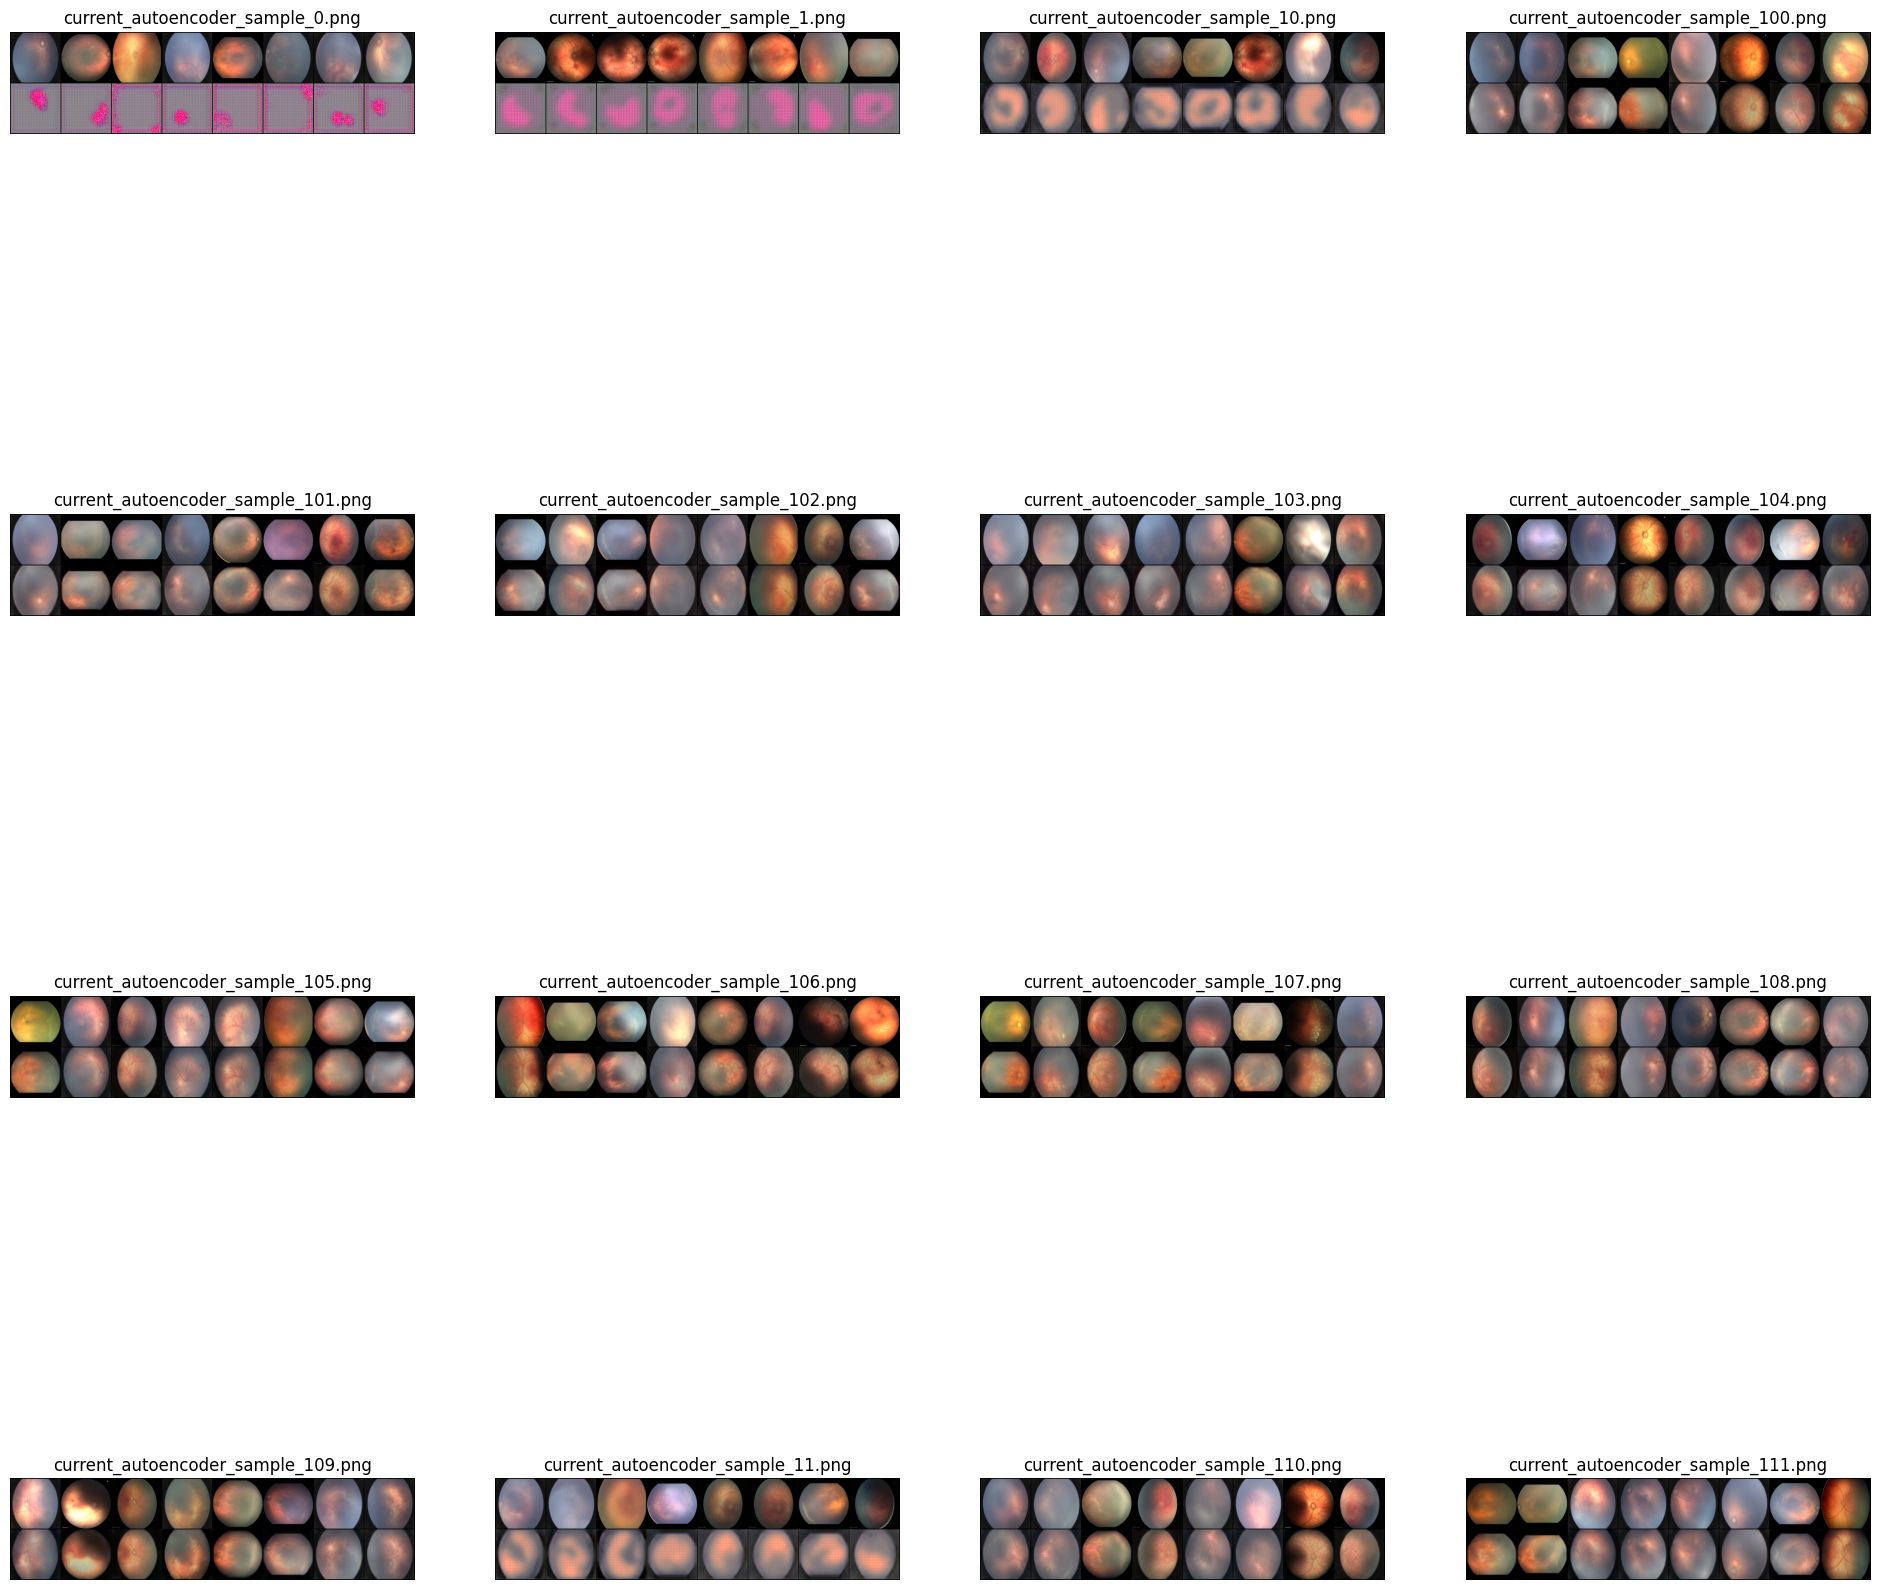

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

samples_dir = "rop/vqvae_autoencoder_samples"
files = sorted(os.listdir(samples_dir))

plt.figure(figsize=(24,24))
for i, f in enumerate(files[:16]):
    img = Image.open(os.path.join(samples_dir, f))
    plt.subplot(4,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f)

plt.show()


In [ ]:
# New cell — visualize 5 RGB originals, their VQ latent indices, and reconstructions
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as T
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- PARAMETERS ---
dataset_root = config['dataset_params']['im_path']  # uses your existing config var
num_samples = 50
im_size = config['dataset_params']['im_size']
im_channels_rgb = 3

# Build a small on-the-fly RGB loader (does NOT modify your files)
def list_image_paths(root, max_items=1000):
    paths = []
    for d in sorted(os.listdir(root)):
        p = os.path.join(root, d)
        if not os.path.isdir(p):
            continue
        for fname in sorted(os.listdir(p)):
            fpath = os.path.join(p, fname)
            if os.path.isfile(fpath):
                paths.append(fpath)
                if len(paths) >= max_items:
                    return paths
    return paths

img_paths = list_image_paths(dataset_root, max_items=200)
if len(img_paths) < num_samples:
    raise RuntimeError(f"Found only {len(img_paths)} images under {dataset_root}; need at least {num_samples}.")

# transform: convert to RGB and normalize to [-1,1] (matching your existing pipeline)
transform = T.Compose([
    T.Resize((im_size, im_size)),
    T.Lambda(lambda img: img.convert('RGB')),   # <-- ensure RGB
    T.ToTensor(),
    T.Normalize([0.5]*im_channels_rgb, [0.5]*im_channels_rgb)
])

# prepare batch of samples (first N)
selected_paths = img_paths[:num_samples]
batch = []
orig_images_for_display = []
for p in selected_paths:
    img = Image.open(p)
    img_rgb = img.convert('RGB')
    orig_images_for_display.append(np.array(img_rgb))  # keep original in uint8 for display
    t = transform(img_rgb)
    batch.append(t)
batch = torch.stack(batch, dim=0).to(device)  # shape (B,3,H,W)

# --- instantiate a new RGB VQVAE ---
# Reuse your earlier autoencoder config but create a fresh model with im_channels=3
rgb_model_config = autoencoder_config.copy()  # uses variable defined earlier in your notebook
model_rgb = VQVAE(im_channels=im_channels_rgb, model_config=rgb_model_config).to(device)

# Try to load your checkpoint if available (gracefully handle mismatch)
ckpt_path = os.path.join(train_config['task_name'], train_config['vqvae_autoencoder_ckpt_name'])
if os.path.exists(ckpt_path):
    try:
        state = torch.load(ckpt_path, map_location=device)
        model_rgb.load_state_dict(state, strict=False)  # allow partial load if shapes differ
        print("Checkpoint loaded into RGB model (strict=False). If the checkpoint was grayscale-trained, some weights will be missing/mismatched.")
    except Exception as e:
        print("Failed to fully load checkpoint into RGB model:", e)
        print("Proceeding with fresh RGB model parameters.")
else:
    print("No checkpoint found at", ckpt_path, " — proceeding with freshly initialized RGB model.")

model_rgb.eval()

# --- run encoder -> quantize (to obtain indices) -> decode ---
with torch.no_grad():
    # Manually run encoder up to pre-quant to capture indices via model.quantize
    x = batch
    out = model_rgb.encoder_conv_in(x)
    for down in model_rgb.encoder_layers:
        out = down(out)
    for mid in model_rgb.encoder_mids:
        out = mid(out)
    out = model_rgb.encoder_norm_out(out)
    out = torch.nn.SiLU()(out)
    out = model_rgb.encoder_conv_out(out)
    pre_quant = model_rgb.pre_quant_conv(out)  # this is the tensor given to quantize

    # quantize: returns quant_out (B,C,h,w), quant_losses, min_encoding_indices (B,h,w)
    quant_out, quant_losses, min_encoding_indices = model_rgb.quantize(pre_quant)

    # decode quantized output to reconstruction
    recon = model_rgb.decode(quant_out)
    # convert recon to CPU numpy images in [0,1]
    recon_vis = ((torch.clamp(recon, -1., 1.) + 1) / 2).cpu().permute(0,2,3,1).numpy()  # B,H,W,3

# prepare latent indices for display (map indices to a colormap)
latent_idx_imgs = min_encoding_indices.cpu().numpy()  # B, h, w
# If needed, resize latent visualization to image size for nicer display (nearest neighbor)
import cv2
latent_vis_resized = []
for idx_map in latent_idx_imgs:
    # normalize indices to 0..1 for mapping
    norm = (idx_map - idx_map.min()) / (idx_map.max() - idx_map.min() + 1e-9)
    # scale to 0..255
    idx_uint8 = np.uint8(norm * 255)
    # resize to display size (nearest to preserve discrete tiles)
    resized = cv2.resize(idx_uint8, (im_size, im_size), interpolation=cv2.INTER_NEAREST)
    latent_vis_resized.append(resized)
latent_vis_resized = np.stack(latent_vis_resized, axis=0)  # B,H,W

# --- PLOT results: each row = sample, columns = original | latent indices | reconstruction ---
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 3 * num_samples))
if num_samples == 1:
    axes = axes[np.newaxis, :]
for i in range(num_samples):
    # original (show resized to im_size to match recon)
    orig = Image.fromarray(orig_images_for_display[i]).resize((im_size, im_size), Image.Resampling.NEAREST)
    axes[i,0].imshow(orig)
    axes[i,0].set_title("Original (RGB)")
    axes[i,0].axis('off')

    # latent indices (colormap)
    axes[i,1].imshow(latent_vis_resized[i], cmap='viridis', interpolation='nearest')
    axes[i,1].set_title("VQ Indices (latent HxW = {})".format(latent_idx_imgs.shape[1:]))
    axes[i,1].axis('off')

    # reconstruction
    axes[i,2].imshow(np.clip(recon_vis[i], 0, 1))
    axes[i,2].set_title("Reconstruction (RGB)")
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

# Additional helpful printouts
print("quantize losses (example):", {k: float(v) for k,v in quant_losses.items()})
print("latent indices shape:", min_encoding_indices.shape, "  (B,H,W). codebook size:", model_rgb.codebook_size)


In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
from segmentation_models_pytorch import UnetPlusPlus
mask_model = UnetPlusPlus(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mask_model.to(device)
mask_model.load_state_dict(torch.load("/content/best_weight_Unet++_maskresize_29", map_location=device))
mask_model.eval()

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

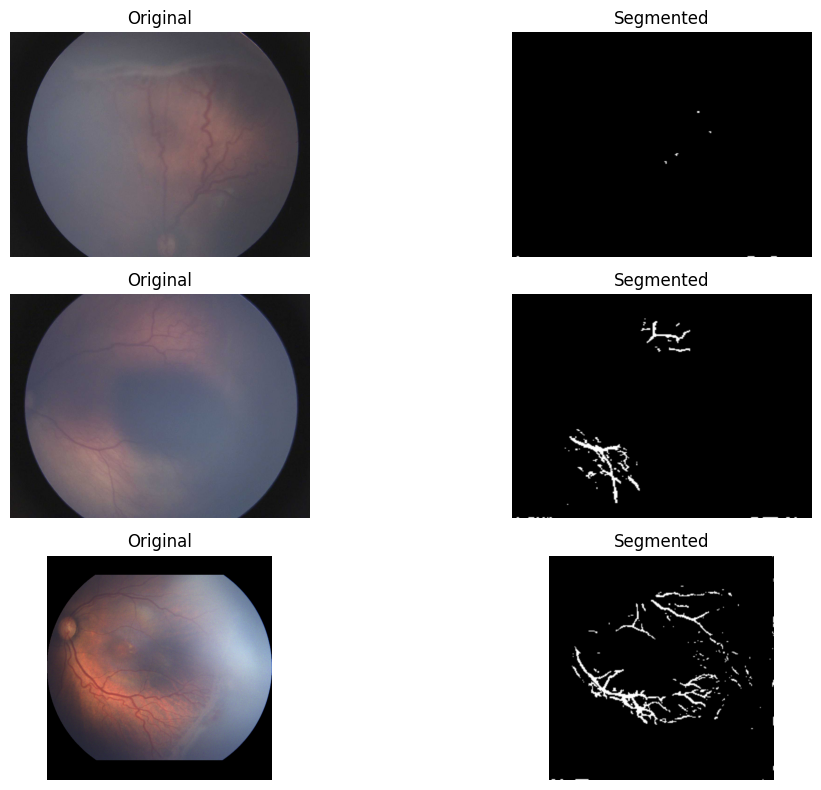

In [ ]:
import os
import glob
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import random

# ImageNet normalization (because encoder_weights="imagenet")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

src_roots = [
    '/content/data/Stage',
    '/content/data/Stage_dataset_2',
    '/content/data/dataset_model',
]

stage_names = ['stage1', 'stage2', 'stage3']

# Collect some random images
all_images = []
for root in src_roots:
    for stage in stage_names:
        stage_path = os.path.join(root, stage)
        if os.path.exists(stage_path):
            all_images += glob.glob(os.path.join(stage_path, '*.jpg'))

# Pick 3 random images
sample_images = random.sample(all_images, min(3, len(all_images)))

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    # resize exactly like before (DO NOT CHANGE)
    resized_image = cv2.resize(image, (256, 256))
    input_tensor = transform(resized_image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mask_model(input_tensor)
        output = torch.sigmoid(output)
        mask = output.squeeze().cpu().numpy()

    mask = (mask > 0.5).astype(np.uint8) * 255
    mask = cv2.resize(mask, (w, h))

    # Plot original
    plt.subplot(3, 2, 2*i+1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')

    # Plot mask
    plt.subplot(3, 2, 2*i+2)
    plt.imshow(mask, cmap='gray')
    plt.title("Segmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import torch
import cv2
import numpy as np
from torchvision import transforms
from tqdm import tqdm

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

for root in src_roots:
    for stage in stage_names:
        stage_path = os.path.join(root, stage)

        if not os.path.exists(stage_path):
            continue

        image_paths = glob.glob(os.path.join(stage_path, '*.jpg'))

        print(f"\nProcessing {len(image_paths)} images in {stage_path}")

        for img_path in tqdm(image_paths):

            if img_path.endswith('_segmented.jpg'):
                continue

            image = cv2.imread(img_path)
            if image is None:
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            h, w = image.shape[:2]

            resized_image = cv2.resize(image, (256, 256))
            input_tensor = transform(resized_image).unsqueeze(0).to(device)

            with torch.no_grad():
                output = mask_model(input_tensor)
                output = torch.sigmoid(output)
                mask = output.squeeze().cpu().numpy()

            mask = (mask > 0.5).astype(np.uint8) * 255
            mask = cv2.resize(mask, (w, h))

            save_path = os.path.splitext(img_path)[0] + '_segmented.jpg'
            cv2.imwrite(save_path, mask)

print("\n✅ All images segmented and saved.")

In [ ]:
!zip -r data.zip data